In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# 剩下所有业务代码

In [2]:
np.random.seed(42)
timesteps = 500

t = np.linspace(0, 8 * np.pi, timesteps)
t

array([ 0.        ,  0.05036621,  0.10073243,  0.15109864,  0.20146486,
        0.25183107,  0.30219729,  0.3525635 ,  0.40292972,  0.45329593,
        0.50366215,  0.55402836,  0.60439458,  0.65476079,  0.70512701,
        0.75549322,  0.80585944,  0.85622565,  0.90659187,  0.95695808,
        1.0073243 ,  1.05769051,  1.10805673,  1.15842294,  1.20878916,
        1.25915537,  1.30952159,  1.3598878 ,  1.41025402,  1.46062023,
        1.51098645,  1.56135266,  1.61171888,  1.66208509,  1.71245131,
        1.76281752,  1.81318374,  1.86354995,  1.91391617,  1.96428238,
        2.0146486 ,  2.06501481,  2.11538103,  2.16574724,  2.21611346,
        2.26647967,  2.31684588,  2.3672121 ,  2.41757831,  2.46794453,
        2.51831074,  2.56867696,  2.61904317,  2.66940939,  2.7197756 ,
        2.77014182,  2.82050803,  2.87087425,  2.92124046,  2.97160668,
        3.02197289,  3.07233911,  3.12270532,  3.17307154,  3.22343775,
        3.27380397,  3.32417018,  3.3745364 ,  3.42490261,  3.47

In [3]:
data = np.sin(t) + 0.1 * np.random.randn(timesteps)
data

array([ 4.96714153e-02,  3.65184930e-02,  1.65331014e-01,  3.02827336e-01,
        1.76689440e-01,  2.25763999e-01,  4.55539924e-01,  4.22048237e-01,
        3.45167679e-01,  4.92186985e-01,  4.36294385e-01,  4.79544282e-01,
        5.92460239e-01,  4.17641499e-01,  4.75638772e-01,  6.29419033e-01,
        6.20142951e-01,  7.86799379e-01,  6.96605024e-01,  6.76212810e-01,
        9.91970591e-01,  8.48646483e-01,  9.01585717e-01,  7.73697369e-01,
        8.80749592e-01,  9.62923960e-01,  8.50962125e-01,  1.01541092e+00,
        9.27076869e-01,  9.64767376e-01,  9.38041261e-01,  1.18518323e+00,
        9.97813067e-01,  8.90064981e-01,  1.07223819e+00,  8.59536144e-01,
        9.91654073e-01,  7.61485826e-01,  8.08891048e-01,  9.43264209e-01,
        9.76950779e-01,  8.97476514e-01,  8.43777689e-01,  7.98065642e-01,
        6.51056871e-01,  6.95631499e-01,  6.88312050e-01,  8.04985618e-01,
        6.96759183e-01,  4.47537312e-01,  6.16111499e-01,  5.03576249e-01,
        4.31398808e-01,  

In [4]:
def create_sliding_window(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i: i + window_size])
        y.append(data[i + window_size])

    return np.array(X), np.array(y)

In [5]:
window_size = 20
X, y = create_sliding_window(data, window_size)

In [6]:
X

array([[ 0.04967142,  0.03651849,  0.16533101, ...,  0.78679938,
         0.69660502,  0.67621281],
       [ 0.03651849,  0.16533101,  0.30282734, ...,  0.69660502,
         0.67621281,  0.99197059],
       [ 0.16533101,  0.30282734,  0.17668944, ...,  0.67621281,
         0.99197059,  0.84864648],
       ...,
       [-0.86370788, -0.56333603, -0.73344822, ..., -0.09686529,
        -0.14621377, -0.25424897],
       [-0.56333603, -0.73344822, -0.83023494, ..., -0.14621377,
        -0.25424897, -0.11959603],
       [-0.73344822, -0.83023494, -0.88296148, ..., -0.25424897,
        -0.11959603, -0.13790675]], shape=(480, 20))

In [7]:
y

array([ 9.91970591e-01,  8.48646483e-01,  9.01585717e-01,  7.73697369e-01,
        8.80749592e-01,  9.62923960e-01,  8.50962125e-01,  1.01541092e+00,
        9.27076869e-01,  9.64767376e-01,  9.38041261e-01,  1.18518323e+00,
        9.97813067e-01,  8.90064981e-01,  1.07223819e+00,  8.59536144e-01,
        9.91654073e-01,  7.61485826e-01,  8.08891048e-01,  9.43264209e-01,
        9.76950779e-01,  8.97476514e-01,  8.43777689e-01,  7.98065642e-01,
        6.51056871e-01,  6.95631499e-01,  6.88312050e-01,  8.04985618e-01,
        6.96759183e-01,  4.47537312e-01,  6.16111499e-01,  5.03576249e-01,
        4.31398808e-01,  5.15999363e-01,  5.12518859e-01,  4.56095716e-01,
        2.31674183e-01,  2.36502508e-01,  2.51699654e-01,  2.66723039e-01,
        7.14172697e-02,  5.06323038e-02, -9.17472897e-02, -1.51094348e-01,
       -5.01172678e-04,  3.79752420e-03, -1.88765874e-01, -1.30489466e-01,
       -2.43371580e-01, -3.92030622e-01, -3.38531891e-01, -2.67070351e-01,
       -4.69591739e-01, -

In [8]:
len(y)

480

In [9]:
print(f"原始数据: {data.shape}")

原始数据: (500,)


In [10]:
print(f"X 形状: {X.shape}")

X 形状: (480, 20)


In [11]:
print(f"y 形状: {y.shape}")

y 形状: (480,)


In [12]:
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [13]:
X_train

array([[0.04967142, 0.03651849, 0.16533101, ..., 0.78679938, 0.69660502,
        0.67621281],
       [0.03651849, 0.16533101, 0.30282734, ..., 0.69660502, 0.67621281,
        0.99197059],
       [0.16533101, 0.30282734, 0.17668944, ..., 0.67621281, 0.99197059,
        0.84864648],
       ...,
       [0.27352138, 0.16811159, 0.37400115, ..., 0.91920054, 1.07167715,
        0.80328967],
       [0.16811159, 0.37400115, 0.39565697, ..., 1.07167715, 0.80328967,
        0.91519015],
       [0.37400115, 0.39565697, 0.5304072 , ..., 0.80328967, 0.91519015,
        0.9855741 ]], shape=(384, 20))

In [14]:
len(y_train)

384

In [15]:
X_train = torch.FloatTensor(X_train).unsqueeze(-1)
X_test = torch.FloatTensor(X_test).unsqueeze(-1)
y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)

In [16]:

print(f"训练集: {X_train.shape}, 测试集: {X_test.shape}")

训练集: torch.Size([384, 20, 1]), 测试集: torch.Size([96, 20, 1])


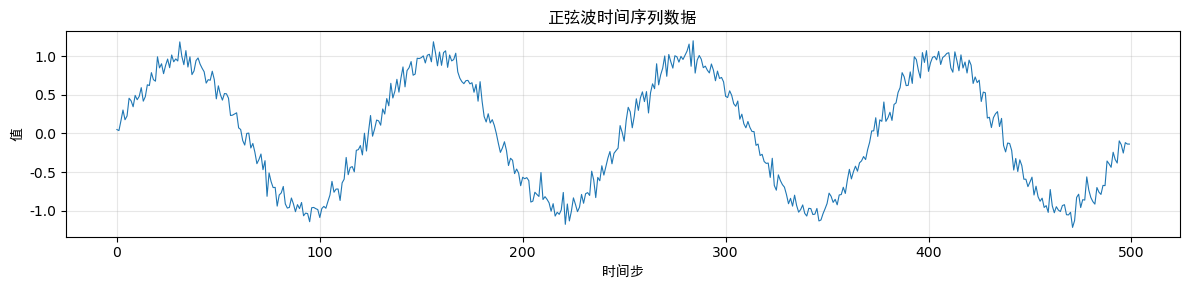

In [17]:
plt.rcParams["font.family"] = ["DejaVu Sans", "SimHei", "Microsoft YaHei"]
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 3))

plt.plot(data, linewidth=0.8)
plt.title("正弦波时间序列数据")
plt.xlabel("时间步")
plt.ylabel("值")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("sine_wave.png", dpi=100)
plt.show()